In [48]:
import pandas as pd
df = pd.read_csv("loan_data.csv")

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   applicant_id       212 non-null    str    
 1   name               212 non-null    str    
 2   age                194 non-null    float64
 3   income             202 non-null    str    
 4   credit_score       195 non-null    float64
 5   loan_amount        212 non-null    float64
 6   employment_status  201 non-null    str    
 7   married            200 non-null    str    
 8   gender             202 non-null    str    
 9   approved           212 non-null    str    
dtypes: float64(3), str(7)
memory usage: 16.7 KB


In [50]:
df.describe()

,age,credit_score,loan_amount
count,194.000000,195.000000,212.000000
mean,43.448454,648.574359,152261.792453
std,20.945523,132.753971,85665.271670
min,-5.000000,0.000000,5000.000000
25%,31.000000,582.500000,88950.000000
50%,41.000000,652.000000,155800.000000
75%,54.000000,737.500000,207575.000000
max,200.000000,850.000000,448800.000000


In [51]:
df.shape

(212, 10)

In [52]:
df.isna().sum()

applicant_id          0
name                  0
age                  18
income               10
credit_score         17
loan_amount           0
employment_status    11
married              12
gender               10
approved              0
dtype: int64

In [53]:
df.head(3)

,applicant_id,name,age,income,credit_score,loan_amount,employment_status,married,gender,approved
0,APP1170,Raj Smith,NaN,"$66,400",NaN,89100.0,Unemployed,No,Female,Rejected
1,APP1177,Omar Silva,25.0,"$75,700",645.0,228600.0,Employed,NaN,Male,Approved
2,APP1132,Mei Khan,24.0,"$26,400",580.0,5000.0,employed,Yes,Female,Approved


In [54]:
df = df.drop(columns=['applicant_id','name'])
df.head(3)

,age,income,credit_score,loan_amount,employment_status,married,gender,approved
0,NaN,"$66,400",NaN,89100.0,Unemployed,No,Female,Rejected
1,25.0,"$75,700",645.0,228600.0,Employed,NaN,Male,Approved
2,24.0,"$26,400",580.0,5000.0,employed,Yes,Female,Approved


In [55]:
duplicated_rows = df[df.duplicated(keep=False)]
print(duplicated_rows)

      age   income  credit_score  loan_amount employment_status married  \
3    28.0  $78,500           NaN     272600.0          Employed      No   
5    26.0  $12,000         574.0      78000.0        Unemployed       Y   
13   47.0  $56,600         627.0     249000.0          employed      no   
16   60.0  $57,700         806.0     117600.0     self employed     NaN   
30   55.0  $47,600         632.0     113300.0          employed     Yes   
38    NaN  $61,300         745.0      70700.0     Self-Employed     yes   
60   36.0    34100         647.0     277800.0          employed      No   
64    NaN  $61,300         745.0      70700.0     Self-Employed     yes   
69   50.0  $26,300         624.0     129000.0     Self Employed     Yes   
73   28.0  $78,500           NaN     272600.0          Employed      No   
94    NaN  $12,000         786.0     126300.0          employed      no   
106  36.0    34100         647.0     277800.0          employed      No   
118  39.0  $62,500       

In [56]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print("Before",before)
print("After",after)

Before 212
After 200


In [57]:
df.shape

(200, 8)

In [58]:
df['income'] = (df['income'].astype(str)
               .str.replace(r'[$,]','',regex=True)
               .str.strip()
        )
df.head(3)

,age,income,credit_score,loan_amount,employment_status,married,gender,approved
0,NaN,66400,NaN,89100.0,Unemployed,No,Female,Rejected
1,25.0,75700,645.0,228600.0,Employed,NaN,Male,Approved
2,24.0,26400,580.0,5000.0,employed,Yes,Female,Approved


In [59]:
df.info()

<class 'pandas.DataFrame'>
Index: 200 entries, 0 to 211
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                184 non-null    float64
 1   income             190 non-null    str    
 2   credit_score       184 non-null    float64
 3   loan_amount        200 non-null    float64
 4   employment_status  190 non-null    str    
 5   married            190 non-null    str    
 6   gender             190 non-null    str    
 7   approved           200 non-null    str    
dtypes: float64(3), str(5)
memory usage: 14.1 KB


In [60]:
df['income'] = pd.to_numeric(df['income'],errors='coerce') # text->number,junk-->Nan
df.head(3)

,age,income,credit_score,loan_amount,employment_status,married,gender,approved
0,NaN,66400.0,NaN,89100.0,Unemployed,No,Female,Rejected
1,25.0,75700.0,645.0,228600.0,Employed,NaN,Male,Approved
2,24.0,26400.0,580.0,5000.0,employed,Yes,Female,Approved


In [61]:
df.info()

<class 'pandas.DataFrame'>
Index: 200 entries, 0 to 211
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                184 non-null    float64
 1   income             188 non-null    float64
 2   credit_score       184 non-null    float64
 3   loan_amount        200 non-null    float64
 4   employment_status  190 non-null    str    
 5   married            190 non-null    str    
 6   gender             190 non-null    str    
 7   approved           200 non-null    str    
dtypes: float64(4), str(4)
memory usage: 14.1 KB


In [62]:
df.gender.value_counts()

gender
Male      37
M         34
female    34
male      31
F         28
Female    26
Name: count, dtype: int64

In [63]:
df['gender'] = df['gender'].map(
    {'male':'Male','m':'Male','female':'Female','f':'Female'}
)

In [64]:
df.gender.value_counts()

gender
Female    34
Male      31
Name: count, dtype: int64

In [65]:
df.married.value_counts()

married
Yes    54
No     34
Y      33
yes    27
N      24
no     18
Name: count, dtype: int64

In [66]:
df['married'] = df['married'].map(
    {'Y':'Yes','yes':'Yes','N':'No','no':'No'}
)

In [67]:
df.married.value_counts()

married
Yes    60
No     42
Name: count, dtype: int64

In [68]:
df.employment_status.value_counts()

employment_status
employed         61
Employed         49
Self-Employed    20
Unemployed       17
unemployed       15
self employed    14
Self Employed    14
Name: count, dtype: int64

In [69]:
emp_map = {
    'employed':'Employed',
    'self employed':'Self-Employed',
    'self-employed':'Self-Employed',
    'unemployed':'Unemployed'
}
df['employment_status'] = df['employment_status'].map(emp_map)
df.employment_status.value_counts()

employment_status
Employed         61
Unemployed       15
Self-Employed    14
Name: count, dtype: int64

In [70]:
df.describe()

,age,income,credit_score,loan_amount
count,184.000000,188.000000,184.000000,200.000000
mean,43.527174,52789.361702,645.951087,151629.500000
std,21.366674,21143.955119,134.420646,86473.742375
min,-5.000000,12000.000000,0.000000,5000.000000
25%,31.000000,37925.000000,581.500000,88250.000000
50%,41.000000,51150.000000,656.000000,157450.000000
75%,54.000000,68325.000000,729.250000,205700.000000
max,200.000000,104000.000000,850.000000,448800.000000


In [71]:
import numpy as np
df.loc[(df['age'] < 18) | (df['age']>100),'age']=np.nan
df.describe()

,age,income,credit_score,loan_amount
count,180.000000,188.000000,184.000000,200.000000
mean,42.327778,52789.361702,645.951087,151629.500000
std,12.861458,21143.955119,134.420646,86473.742375
min,21.000000,12000.000000,0.000000,5000.000000
25%,31.000000,37925.000000,581.500000,88250.000000
50%,41.000000,51150.000000,656.000000,157450.000000
75%,54.000000,68325.000000,729.250000,205700.000000
max,64.000000,104000.000000,850.000000,448800.000000


In [72]:
df.loc[(df['credit_score'] < 300) | (df['credit_score']>850),'credit_score']=np.nan
df.describe()

,age,income,credit_score,loan_amount
count,180.000000,188.000000,180.000000,200.000000
mean,42.327778,52789.361702,660.288889,151629.500000
std,12.861458,21143.955119,94.675836,86473.742375
min,21.000000,12000.000000,425.000000,5000.000000
25%,31.000000,37925.000000,584.000000,88250.000000
50%,41.000000,51150.000000,665.500000,157450.000000
75%,54.000000,68325.000000,731.750000,205700.000000
max,64.000000,104000.000000,850.000000,448800.000000


In [73]:
df.isna().sum()

age                   20
income                12
credit_score          20
loan_amount            0
employment_status    110
married               98
gender               135
approved               0
dtype: int64

In [74]:
df['age']=df['age'].fillna(df.age.median())

In [75]:
df.isna().sum()

age                    0
income                12
credit_score          20
loan_amount            0
employment_status    110
married               98
gender               135
approved               0
dtype: int64

In [76]:
num_cols = ['age','income','credit_score','loan_amount']

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

df.isna().sum()

age                    0
income                 0
credit_score           0
loan_amount            0
employment_status    110
married               98
gender               135
approved               0
dtype: int64

In [77]:
df.employment_status.value_counts()

employment_status
Employed         61
Unemployed       15
Self-Employed    14
Name: count, dtype: int64

In [79]:
df.employment_status.mode()

0    Employed
Name: employment_status, dtype: str

In [78]:
num_cols = ['employment_status','married','credit_score','gender']

for c in num_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

df.isna().sum()

age                  0
income               0
credit_score         0
loan_amount          0
employment_status    0
married              0
gender               0
approved             0
dtype: int64

In [80]:
df.head()

,age,income,credit_score,loan_amount,employment_status,married,gender,approved
0,41.0,66400.0,665.5,89100.0,Employed,Yes,Female,Rejected
1,25.0,75700.0,645.0,228600.0,Employed,Yes,Female,Approved
2,24.0,26400.0,580.0,5000.0,Employed,Yes,Female,Approved
3,28.0,78500.0,665.5,272600.0,Employed,Yes,Female,Approved
4,35.0,51150.0,573.0,159000.0,Employed,No,Female,Rejected


In [81]:
df['approved'] = df['approved'].map({'Approved':1,'Rejected':0})
df.head(3)

,age,income,credit_score,loan_amount,employment_status,married,gender,approved
0,41.0,66400.0,665.5,89100.0,Employed,Yes,Female,0
1,25.0,75700.0,645.0,228600.0,Employed,Yes,Female,1
2,24.0,26400.0,580.0,5000.0,Employed,Yes,Female,1


In [82]:
df = pd.get_dummies(df,columns=['gender','employment_status','married'],drop_first=True)
df.head()

,age,income,credit_score,loan_amount,approved,gender_Male,employment_status_Self-Employed,employment_status_Unemployed,married_Yes
0,41.0,66400.0,665.5,89100.0,0,False,False,False,True
1,25.0,75700.0,645.0,228600.0,1,False,False,False,True
2,24.0,26400.0,580.0,5000.0,1,False,False,False,True
3,28.0,78500.0,665.5,272600.0,1,False,False,False,True
4,35.0,51150.0,573.0,159000.0,0,False,False,False,False


In [85]:
num_cols = ['age','income','credit_score','loan_amount']
df[num_cols]

,age,income,credit_score,loan_amount
0,41.0,66400.0,665.5,89100.0
1,25.0,75700.0,645.0,228600.0
2,24.0,26400.0,580.0,5000.0
3,28.0,78500.0,665.5,272600.0
4,35.0,51150.0,573.0,159000.0
...,...,...,...,...
206,34.0,28800.0,665.5,162900.0
208,54.0,103000.0,818.0,89900.0
209,55.0,64600.0,688.0,47600.0
210,30.0,40500.0,669.0,290300.0


In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()

,age,income,credit_score,loan_amount
0,-0.098160,0.670402,0.052355,-0.724918
1,-1.412433,1.125193,-0.176488,0.892336
2,-1.494575,-1.285690,-0.902087,-1.699909
3,-1.166007,1.262119,0.052355,1.402438
4,-0.591012,-0.075358,-0.980228,0.085448


In [87]:
df[num_cols].describe()

,age,income,credit_score,loan_amount
count,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,-3.108624e-17,-8.881784e-18,5.995204e-16,-1.998401e-17
std,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.741001e+00,-1.989883e+00,-2.632361e+00,-1.699909e+00
25%,-7.552964e-01,-6.805243e-01,-7.569670e-01,-7.347727e-01
50%,-9.815978e-02,-7.535844e-02,5.235474e-02,6.747836e-02
75%,8.054031e-01,6.483955e-01,7.388828e-01,6.268514e-01
max,1.791108e+00,2.509128e+00,2.111939e+00,3.445164e+00


In [88]:
df.head()

,age,income,credit_score,loan_amount,approved,gender_Male,employment_status_Self-Employed,employment_status_Unemployed,married_Yes
0,-0.098160,0.670402,0.052355,-0.724918,0,False,False,False,True
1,-1.412433,1.125193,-0.176488,0.892336,1,False,False,False,True
2,-1.494575,-1.285690,-0.902087,-1.699909,1,False,False,False,True
3,-1.166007,1.262119,0.052355,1.402438,1,False,False,False,True
4,-0.591012,-0.075358,-0.980228,0.085448,0,False,False,False,False


In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['approved'])
y = df['approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

print(f"Test accuracy: {model.score(X_test, y_test):.2f}")

Test accuracy: 0.65


In [90]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.67      0.78      0.72        23
           1       0.62      0.47      0.53        17

    accuracy                           0.65        40
   macro avg       0.64      0.63      0.63        40
weighted avg       0.64      0.65      0.64        40



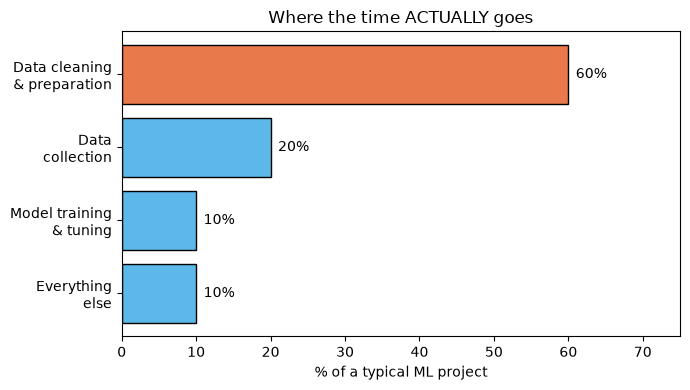

In [91]:
import matplotlib.pyplot as plt

tasks = ['Data cleaning\n& preparation', 'Data\ncollection',
         'Model training\n& tuning', 'Everything\nelse']
share = [60, 20, 10, 10]  # approximate, typical ML project
bar_colors = ['#E8794B', '#5BB8E8', '#5BB8E8', '#5BB8E8']

plt.figure(figsize=(7, 4))
plt.barh(tasks, share, color=bar_colors, edgecolor='k')
plt.gca().invert_yaxis()
plt.xlabel('% of a typical ML project')
plt.title('Where the time ACTUALLY goes')
for i, v in enumerate(share):
    plt.text(v + 1, i, f'{v}%', va='center')
plt.xlim(0, 75)
plt.tight_layout()
plt.show()